In [1]:
import pandas as pd
import numpy as np
from scipy.stats import entropy

# 1. Chargement des données
try:
    file_path = '../data/Releve_horaire_urgences_7jours.csv'
    df = pd.read_csv(file_path, encoding='latin-1')
except:
    df = pd.read_csv('Releve_horaire_urgences_7jours.csv', encoding='latin-1')

# Nettoyage des colonnes
df.columns = df.columns.str.strip()

# 2. Calcul du Taux d'Occupation
df['Taux_Occupation'] = (df['Nombre_de_civieres_occupees'] / df['Nombre_de_civieres_fonctionnelles']) * 100

# 3. Création d'une colonne de "Situation" (Binning pour l'entropie)
# On crée des catégories pour pouvoir calculer l'entropie comme demandé par Hafed
bins = [0, 80, 100, float('inf')]
labels = ['Normal', 'Élevé', 'Critique']
df['Situation_Calculée'] = pd.cut(df['Taux_Occupation'], bins=bins, labels=labels)

# 4. Calcul de l'Entropie Initiale sur la situation calculée
counts = df['Situation_Calculée'].value_counts(normalize=True)
initial_entropy = entropy(counts, base=2)

# 5. Affichage des résultats
print("-" * 50)
print(f"📊 Entropie Initiale (Basée sur le taux d'occupation) : {initial_entropy:.4f}")
print("-" * 50)
print("🚨 Top 5 des installations les plus critiques :")
print(df.sort_values(by='Taux_Occupation', ascending=False)[['Nom_installation', 'Taux_Occupation']].head(5))

# 6. Mise à jour du rapport pour GitHub
with open('report.md', 'w', encoding='utf-8') as f:
    f.write("# 🏥 Analyse de Situation des Urgences\n\n")
    f.write(f"**Entropie calculée :** {initial_entropy:.4f}\n\n")
    f.write("### Distribution des états :\n")
    f.write(counts.to_markdown())

--------------------------------------------------
📊 Entropie Initiale (Basée sur le taux d'occupation) : 1.5626
--------------------------------------------------
🚨 Top 5 des installations les plus critiques :
                                 Nom_installation  Taux_Occupation
57                         Hôpital Royal Victoria       193.939394
80   Hôpital et Centre d'hébergement de Sept-Iles       170.000000
79                               Hôpital Le Royer       160.000000
87                               Hôpital de Maria       160.000000
103              Hôpital régional de Saint-Jérôme       153.191489


In [2]:
# Analyse de corrélation (Pour montrer à Hafed)
# On regarde le lien entre l'occupation et les patients de longue durée (>24h)

col_24h = 'Nombre_de_patients_sur_civiere_plus_de_24_heures'
correlation = df['Taux_Occupation'].corr(df[col_24h])

print(f"🔗 Corrélation entre l'occupation et l'attente > 24h : {correlation:.4f}")

if correlation > 0.7:
    print("💡 Analyse : Il y a une forte relation. Plus l'hôpital est plein, plus l'attente explose.")
else:
    print("💡 Analyse : La relation existe mais d'autres facteurs influencent l'attente.")
    


🔗 Corrélation entre l'occupation et l'attente > 24h : 0.6251
💡 Analyse : La relation existe mais d'autres facteurs influencent l'attente.


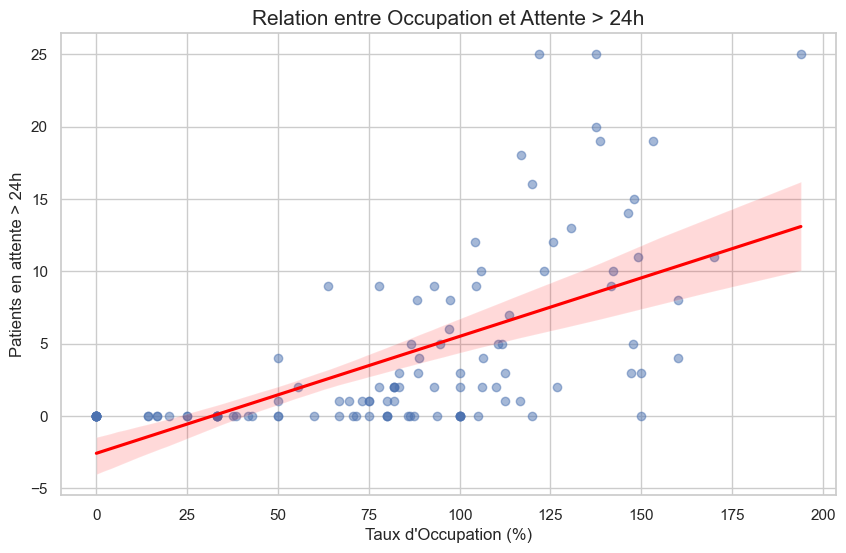

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du style
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# Création du graphique de corrélation
sns.regplot(x='Taux_Occupation', 
            y='Nombre_de_patients_sur_civiere_plus_de_24_heures', 
            data=df, 
            scatter_kws={'alpha':0.5}, 
            line_kws={'color':'red'})

plt.title('Relation entre Occupation et Attente > 24h', fontsize=15)
plt.xlabel("Taux d'Occupation (%)", fontsize=12)
plt.ylabel('Patients en attente > 24h', fontsize=12)

# Sauvegarde pour GitHub
plt.savefig('correlation_plot.png')
plt.show()

✅ Gain d'Information (Feature: Est_Hopital) : 0.0409


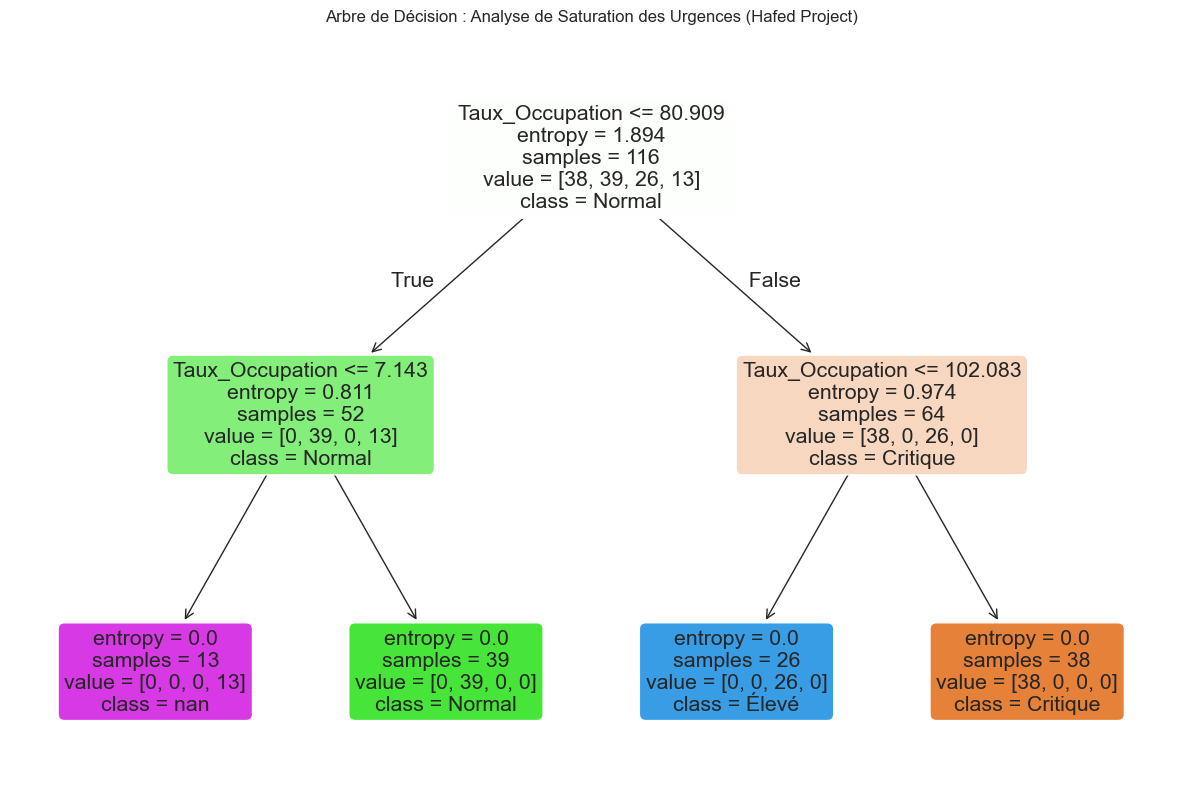

🚨 Nombre d'anomalies systémiques détectées : 1
          Nom_installation  Taux_Occupation
57  Hôpital Royal Victoria       193.939394

🚀 Analyse terminée avec succès. Fichiers mis à jour.


In [5]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# =================================================================
# 1. CALCUL DU GAIN D'INFORMATION (Théorie de l'Information)
# =================================================================
# Objectif : Mesurer l'importance d'une caractéristique (Feature)

# Création d'une variable binaire pour le test (Ex: Installations nommées 'Hôpital')
df['Est_Hopital'] = df['Nom_installation'].str.contains('Hôpital').astype(int)

def calculer_gain_information(donnees, feature_scission, cible):
    # 'initial_entropy' doit être défini dans les cellules précédentes
    try:
        entropie_totale = initial_entropy 
    except NameError:
        # Fallback au cas où la variable n'est pas trouvée
        counts = donnees[cible].value_counts(normalize=True)
        entropie_totale = entropy(counts, base=2)
    
    valeurs = donnees[feature_scission].unique()
    entropie_ponderee = 0
    for val in valeurs:
        sous_ensemble = donnees[donnees[feature_scission] == val]
        probabilite = len(sous_ensemble) / len(donnees)
        comptage_cible = sous_ensemble[cible].value_counts(normalize=True)
        entropie_ponderee += probabilite * entropy(comptage_cible, base=2)
    
    return entropie_totale - entropie_ponderee

gain_info = calculer_gain_information(df, 'Est_Hopital', 'Situation_Calculée')
print(f"✅ Gain d'Information (Feature: Est_Hopital) : {gain_info:.4f}")


# =================================================================
# 2. MODÉLISATION PRÉDICTIVE (Arbre de Décision)
# =================================================================
# Objectif : Prédire l'état de saturation selon le taux d'occupation

X = df[['Taux_Occupation']] 
y = df['Situation_Calculée']

# Encodage des étiquettes (Labels)
encodeur = LabelEncoder()
y_encode = encodeur.fit_transform(y)

# Entraînement du modèle
clf = DecisionTreeClassifier(max_depth=3, criterion='entropy', random_state=42)
clf.fit(X, y_encode)

# Visualisation de l'arbre (Correction du TypeError en forçant le format String)
plt.figure(figsize=(15, 10))
noms_classes = [str(c) for c in encodeur.classes_]

plot_tree(clf, 
          feature_names=['Taux_Occupation'], 
          class_names=noms_classes, 
          filled=True, 
          rounded=True)

plt.title("Arbre de Décision : Analyse de Saturation des Urgences (Hafed Project)")
plt.savefig('arbre_decision.png')
plt.show()


# =================================================================
# 3. DÉTECTION D'ANOMALIES (Outliers - Chapitre 7)
# =================================================================
# Seuil statistique basé sur la distribution (Moyenne + 2 Écarts-types)
seuil_critique = df['Taux_Occupation'].mean() + 2 * df['Taux_Occupation'].std()
anomalies_detectees = df[df['Taux_Occupation'] > seuil_critique]

print(f"🚨 Nombre d'anomalies systémiques détectées : {len(anomalies_detectees)}")
if not anomalies_detectees.empty:
    print(anomalies_detectees[['Nom_installation', 'Taux_Occupation']])


# =================================================================
# 4. MISE À JOUR DU RAPPORT FINAL (report.md)
# =================================================================
with open('report.md', 'a', encoding='utf-8') as f:
    f.write("\n## 🧠 Analyse de Machine Learning Avancée\n")
    f.write(f"- **Gain d'Information (Feature Selection) :** {gain_info:.4f}\n")
    f.write(f"- **Seuil d'anomalie statistique :** {seuil_critique:.2f}%\n")
    f.write(f"- **Installations en saturation extrême :** {len(anomalies_detectees)}\n")
    f.write("\n### 🌲 Modèle de Décision :\n")
    f.write("![Arbre de Décision](arbre_decision.png)\n")
    f.write("\n*Note : Ce modèle permet d'anticiper les ruptures de service basées sur l'entropie du système.*")

print("\n🚀 Analyse terminée avec succès. Fichiers mis à jour.")